# Fine-Tuning a Vision Transformer (ViT) for Blood Cell Classification

This notebook fine-tunes `google/vit-base-patch16-224` on the
[`ehottl/blood_dataset`](https://huggingface.co/datasets/ehottl/blood_dataset)
(46,232 microscope images across 8 blood cell classes: basophil, eosinophil,
erythroblast, lymphocyte, monocyte, neutrophil, platelet, plasma cell).

**Pipeline:** load & split data → preprocess with `ViTImageProcessor` →
fine-tune with `Trainer` → evaluate (accuracy, F1, confusion matrix) →
push to Hub (optional) → interactive Gradio demo (optional).

Runs end-to-end on a free Colab T4 GPU. Runtime: **GPU** (Runtime → Change runtime type → T4 GPU).


## 1. Setup

If you opened this notebook standalone (e.g. via "Open in Colab" badge without
cloning the repo), run the clone cell below so relative paths to
`../configs/config.yaml` and `../results/` resolve correctly. Skip it if
you've already mounted/cloned the repo another way.

In [1]:
# Optional: clone the repo so configs/ and results/ are available at ../
import os

REPO_URL = "https://githubtocolab.com/Praruj/vit-biomedical-finetuning.git"

if not os.path.exists("/content/vit-biomedical-finetuning") and "google.colab" in str(get_ipython()):
    !git clone -q {REPO_URL}
    %cd vit-biomedical-finetuning/notebooks

fatal: unable to access 'https://githubtocolab.com/Praruj/vit-biomedical-finetuning.git/': The requested URL returned error: 400
[Errno 2] No such file or directory: 'vit-biomedical-finetuning/notebooks'
/content


### Mount Google Drive (recommended)

Colab wipes local disk when the runtime disconnects — mounting Drive means
your trained model checkpoint survives even if the session times out or you
close the tab. Skip this cell if you don't mind retraining from scratch each
session.

In [3]:
USE_DRIVE = True  # set False to keep everything local to the Colab runtime (not persisted)

if USE_DRIVE and "google.colab" in str(get_ipython()):
    from google.colab import drive
    drive.mount("/content/drive")
    DRIVE_OUTPUT_DIR = "/content/drive/MyDrive/vit-biomedical-finetuning/results"
    print(f"Model checkpoints will be saved to: {DRIVE_OUTPUT_DIR}")
else:
    DRIVE_OUTPUT_DIR = None
    print("Not using Drive — output will only exist for this Colab session.")

Mounted at /content/drive
Model checkpoints will be saved to: /content/drive/MyDrive/vit-biomedical-finetuning/results


In [4]:
!pip install -q transformers datasets accelerate evaluate scikit-learn gradio torch torchvision pyyaml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.3 MB/s eta 0:00:00


### Mount Google Drive (persist your trained model!)

Colab wipes local disk when the runtime disconnects — if you don't save
to Drive, a trained model is gone the moment the session ends. Run this
cell once per session; it'll ask you to authorize access.

In [5]:
IN_COLAB = "google.colab" in str(get_ipython())

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    DRIVE_OUTPUT_DIR = "/content/drive/MyDrive/vit-biomedical-finetuning/results"
    print(f"Drive mounted. Model checkpoints will be saved to: {DRIVE_OUTPUT_DIR}")
else:
    DRIVE_OUTPUT_DIR = None  # running locally — config.yaml's output_dir is used as-is

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted. Model checkpoints will be saved to: /content/drive/MyDrive/vit-biomedical-finetuning/results


In [6]:
import torch
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device:", torch.cuda.get_device_name(0))

Torch: 2.11.0+cu128
CUDA available: True
Device: Tesla T4


### Load config

All hyperparameters live in `configs/config.yaml` rather than hardcoded in the
notebook, so the run is easy to reproduce/tweak without touching code. If
you're running this in Colab without cloning the repo, the fallback default
config below is used instead.

In [7]:
import yaml
import os

CONFIG_PATH = "../configs/config.yaml"  # relative path if repo is cloned into Colab

default_config = {
    "model": {"checkpoint": "google/vit-base-patch16-224", "num_labels": 8},
    "dataset": {"name": "ehottl/blood_dataset", "train_split": 0.8, "val_split": 0.1,
                "test_split": 0.1, "seed": 42},
    "preprocessing": {"image_size": 224},
    "training": {
        "output_dir": "results/vit-blood-cell-classifier",
        "per_device_train_batch_size": 32,
        "per_device_eval_batch_size": 32,
        "gradient_accumulation_steps": 1,
        "num_train_epochs": 4,
        "learning_rate": 2e-5,
        "warmup_ratio": 0.1,
        "weight_decay": 0.01,
        "fp16": True,
        "eval_strategy": "epoch",
        "save_strategy": "epoch",
        "logging_steps": 50,
        "load_best_model_at_end": True,
        "metric_for_best_model": "f1_macro",
        "save_total_limit": 2,
    },
    "hub": {"push_to_hub": False, "repo_id": "your-hf-username/vit-blood-cell-classifier"},
}

if os.path.exists(CONFIG_PATH):
    with open(CONFIG_PATH) as f:
        cfg = yaml.safe_load(f)
    print(f"Loaded config from {CONFIG_PATH}")
else:
    cfg = default_config
    print("configs/config.yaml not found — using built-in default config "
          "(clone the full repo into Colab to use configs/config.yaml directly).")

# Save checkpoints to Drive if mounted, so training survives a disconnect
if DRIVE_OUTPUT_DIR:
    cfg["training"]["output_dir"] = DRIVE_OUTPUT_DIR

cfg

configs/config.yaml not found — using built-in default config (clone the full repo into Colab to use configs/config.yaml directly).


{'model': {'checkpoint': 'google/vit-base-patch16-224', 'num_labels': 8},
 'dataset': {'name': 'ehottl/blood_dataset',
  'train_split': 0.8,
  'val_split': 0.1,
  'test_split': 0.1,
  'seed': 42},
 'preprocessing': {'image_size': 224},
 'training': {'output_dir': '/content/drive/MyDrive/vit-biomedical-finetuning/results',
  'per_device_train_batch_size': 32,
  'per_device_eval_batch_size': 32,
  'gradient_accumulation_steps': 1,
  'num_train_epochs': 4,
  'learning_rate': 2e-05,
  'warmup_ratio': 0.1,
  'weight_decay': 0.01,
  'fp16': True,
  'eval_strategy': 'epoch',
  'save_strategy': 'epoch',
  'logging_steps': 50,
  'load_best_model_at_end': True,
  'metric_for_best_model': 'f1_macro',
  'save_total_limit': 2},
 'hub': {'push_to_hub': False,
  'repo_id': 'your-hf-username/vit-blood-cell-classifier'}}

### (Optional) Hugging Face login

Only needed if you plan to **push the fine-tuned model to the Hub**.
Skip this cell entirely if you just want to train and evaluate locally in Colab.

In [8]:
PUSH_TO_HUB = cfg["hub"]["push_to_hub"]  # flip to True in configs/config.yaml to upload

if PUSH_TO_HUB:
    from huggingface_hub import notebook_login
    notebook_login()

## 2. Load the dataset

In [9]:
from datasets import load_dataset

raw_dataset = load_dataset(cfg["dataset"]["name"])
print(raw_dataset)

README.md:   0%|          | 0.00/3.17k [00:00<?, ?B/s]

train/data-00000-of-00011.arrow: reconstructing file:   0%|          |  0.00B /  221MB            

train/data-00000-of-00011.arrow: downloading bytes:           |  0.00B            

train/data-00001-of-00011.arrow: reconstructing file:   0%|          |  0.00B /  339MB            

train/data-00001-of-00011.arrow: downloading bytes:           |  0.00B            

...

train/data-00009-of-00011.arrow: downloading bytes:           |  0.00B            

train/data-00010-of-00011.arrow: reconstructing file:   0%|          |  0.00B /  474MB            

train/data-00010-of-00011.arrow: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/46232 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 46232
    })
})


The dataset only ships a single `train` split (46,232 examples), so we
create our own train / validation / test splits (80 / 10 / 10).

In [10]:
ds_cfg = cfg["dataset"]
val_test_size = ds_cfg["val_split"] + ds_cfg["test_split"]
test_of_holdout = ds_cfg["test_split"] / val_test_size  # relative fraction within the holdout

split_1 = raw_dataset["train"].train_test_split(test_size=val_test_size, seed=ds_cfg["seed"], stratify_by_column="label")
split_2 = split_1["test"].train_test_split(test_size=test_of_holdout, seed=ds_cfg["seed"], stratify_by_column="label")

from datasets import DatasetDict

dataset = DatasetDict({
    "train": split_1["train"],
    "validation": split_2["train"],
    "test": split_2["test"],
})
dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 36985
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 4623
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 4624
    })
})

In [11]:
labels = dataset["train"].features["label"].names
num_labels = len(labels)
id2label = {i: name for i, name in enumerate(labels)}
label2id = {name: i for i, name in enumerate(labels)}

print(f"{num_labels} classes:", labels)

8 classes: ['Basophil', 'Eosinophil', 'Erythroblast', 'Lymphocyte', 'Monocyte', 'Neutrophil', 'PlasmaCell', 'Platelet']


In [12]:
# Quick peek at class balance in the training split
import pandas as pd

counts = pd.Series(dataset["train"]["label"]).value_counts().rename(index=id2label)
counts

,count
Neutrophil,13889
Lymphocyte,6345
Eosinophil,5853
Monocyte,4248
PlasmaCell,2316
Platelet,1878
Erythroblast,1241
Basophil,1215


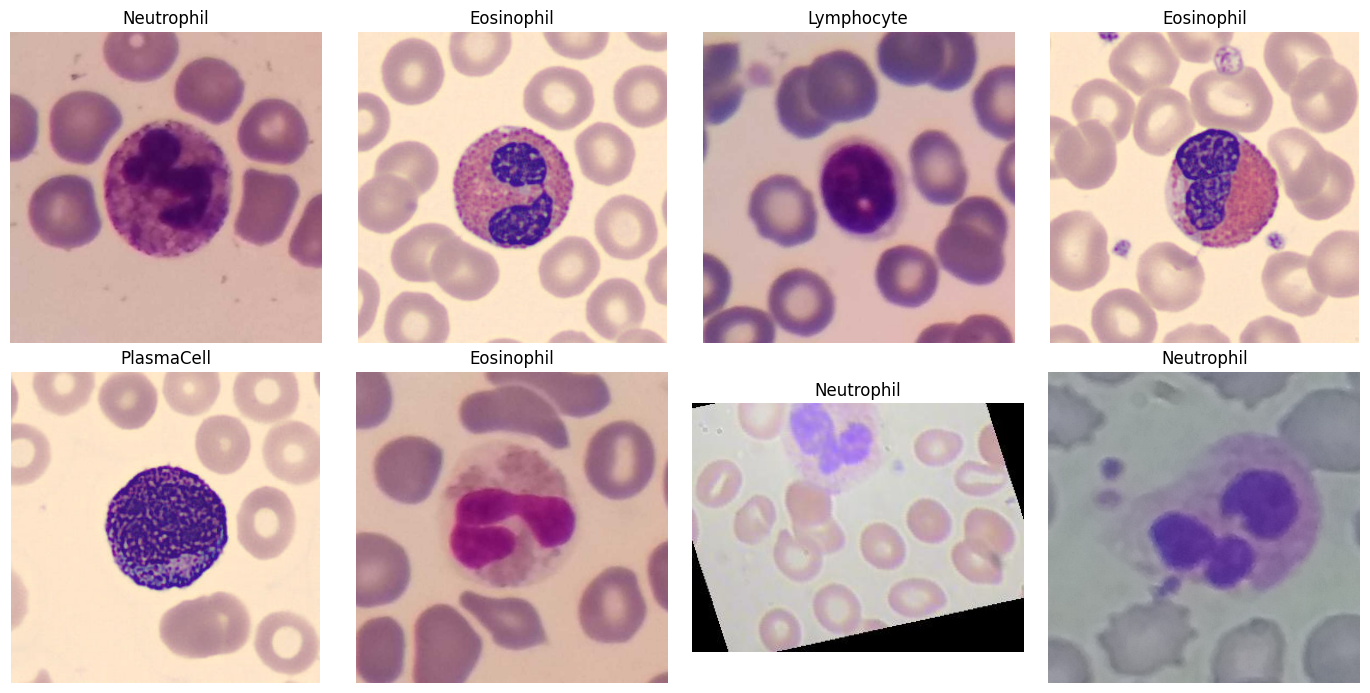

In [13]:
# Visualize a few samples
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax in axes.flatten():
    idx = torch.randint(0, len(dataset["train"]), (1,)).item()
    example = dataset["train"][idx]
    ax.imshow(example["image"])
    ax.set_title(id2label[example["label"]])
    ax.axis("off")
plt.tight_layout()
plt.show()

## 3. Preprocessing

In [14]:
from transformers import ViTImageProcessor

model_checkpoint = cfg["model"]["checkpoint"]
processor = ViTImageProcessor.from_pretrained(model_checkpoint)
processor

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

ViTImageProcessor {
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.5,
    0.5,
    0.5
  ],
  "image_processor_type": "ViTImageProcessor",
  "image_std": [
    0.5,
    0.5,
    0.5
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 224,
    "width": 224
  }
}

In [15]:
from torchvision.transforms import (
    Compose, Normalize, RandomHorizontalFlip, RandomRotation,
    RandomResizedCrop, Resize, CenterCrop, ToTensor,
)

image_mean, image_std = processor.image_mean, processor.image_std
size = cfg["preprocessing"].get("image_size", processor.size["height"])

normalize = Normalize(mean=image_mean, std=image_std)

train_transforms = Compose([
    RandomResizedCrop(size),
    RandomHorizontalFlip(),
    RandomRotation(10),
    ToTensor(),
    normalize,
])

eval_transforms = Compose([
    Resize(size),
    CenterCrop(size),
    ToTensor(),
    normalize,
])

def apply_train_transforms(batch):
    batch["pixel_values"] = [train_transforms(img.convert("RGB")) for img in batch["image"]]
    return batch

def apply_eval_transforms(batch):
    batch["pixel_values"] = [eval_transforms(img.convert("RGB")) for img in batch["image"]]
    return batch

dataset["train"].set_transform(apply_train_transforms)
dataset["validation"].set_transform(apply_eval_transforms)
dataset["test"].set_transform(apply_eval_transforms)

In [16]:
def collate_fn(batch):
    pixel_values = torch.stack([item["pixel_values"] for item in batch])
    labels = torch.tensor([item["label"] for item in batch])
    return {"pixel_values": pixel_values, "labels": labels}

## 4. Load the model

In [17]:
from transformers import ViTForImageClassification

assert num_labels == cfg["model"]["num_labels"], (
    f"Dataset has {num_labels} classes but config.yaml specifies "
    f"{cfg['model']['num_labels']} — update configs/config.yaml."
)

model = ViTForImageClassification.from_pretrained(
    model_checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,  # replaces the original 1000-class head
)

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

[transformers] You passed `num_labels=8` which is incompatible to the `id2label` map of length `1000`.


model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([8])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([8, 768])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


## 5. Metrics

In [18]:
import numpy as np
import evaluate

accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    predictions = np.argmax(eval_pred.predictions, axis=1)
    references = eval_pred.label_ids
    acc = accuracy_metric.compute(predictions=predictions, references=references)
    f1 = f1_metric.compute(predictions=predictions, references=references, average="macro")
    return {"accuracy": acc["accuracy"], "f1_macro": f1["f1"]}

## 6. Training

Settings below are tuned for a free-tier Colab **T4 (16GB)** GPU:
- `fp16=True` for mixed precision (much faster, lower memory on T4)
- Small-ish batch size with gradient accumulation to keep memory in check
- `remove_unused_columns=False` because we handle the image/label mapping ourselves via `set_transform`


In [20]:
import inspect
from transformers import TrainingArguments, Trainer

t_cfg = cfg["training"]
output_dir = t_cfg["output_dir"]

# Only pass kwargs that this installed version of TrainingArguments actually accepts
valid_keys = set(inspect.signature(TrainingArguments.__init__).parameters.keys())

candidate_args = {
    "output_dir": output_dir,
    "per_device_train_batch_size": t_cfg["per_device_train_batch_size"],
    "per_device_eval_batch_size": t_cfg["per_device_eval_batch_size"],
    "gradient_accumulation_steps": t_cfg["gradient_accumulation_steps"],
    "num_train_epochs": t_cfg["num_train_epochs"],
    "learning_rate": float(t_cfg["learning_rate"]),
    "warmup_ratio": t_cfg["warmup_ratio"],
    "weight_decay": t_cfg["weight_decay"],
    "fp16": t_cfg["fp16"] and torch.cuda.is_available(),
    "eval_strategy": t_cfg["eval_strategy"],
    "evaluation_strategy": t_cfg["eval_strategy"],  # older transformers used this name instead
    "save_strategy": t_cfg["save_strategy"],
    "logging_steps": t_cfg["logging_steps"],
    "load_best_model_at_end": t_cfg["load_best_model_at_end"],
    "metric_for_best_model": t_cfg["metric_for_best_model"],
    "save_total_limit": t_cfg["save_total_limit"],
    "remove_unused_columns": False,
    "report_to": "none",
    "push_to_hub": False,
}

filtered_args = {k: v for k, v in candidate_args.items() if k in valid_keys}
dropped = set(candidate_args) - set(filtered_args)
if dropped:
    print(f"Note: this transformers version doesn't support: {dropped} — skipped.")

training_args = TrainingArguments(**filtered_args)

Note: this transformers version doesn't support: {'evaluation_strategy', 'warmup_ratio'} — skipped.


In [23]:
import inspect

trainer_valid_keys = set(inspect.signature(Trainer.__init__).parameters.keys())
processor_kwarg = "processing_class" if "processing_class" in trainer_valid_keys else "tokenizer"

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["validation"],
    data_collator=collate_fn,
    compute_metrics=compute_metrics,
    **{processor_kwarg: processor},
)

In [24]:
train_results = trainer.train()
trainer.save_model()
trainer.log_metrics("train", train_results.metrics)
trainer.save_metrics("train", train_results.metrics)

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.208321,0.130704,0.952196,0.958899
2,0.142223,0.050512,0.981397,0.981583
3,0.108501,0.047991,0.981614,0.982034
4,0.109570,0.036994,0.985291,0.984969


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['vit.layers.0.attention.q_proj.weight', 'vit.layers.0.attention.q_proj.bias', 'vit.layers.0.attention.k_proj.weight', 'vit.layers.0.attention.k_proj.bias', 'vit.layers.0.attention.v_proj.weight', 'vit.layers.0.attention.v_proj.bias', 'vit.layers.0.attention.o_proj.weight', 'vit.layers.0.attention.o_proj.bias', 'vit.layers.0.layernorm_before.weight', 'vit.layers.0.layernorm_before.bias', 'vit.layers.0.layernorm_after.weight', 'vit.layers.0.layernorm_after.bias', 'vit.layers.0.mlp.fc1.weight', 'vit.layers.0.mlp.fc1.bias', 'vit.layers.0.mlp.fc2.weight', 'vit.layers.0.mlp.fc2.bias', 'vit.layers.1.attention.q_proj.weight', 'vit.layers.1.attention.q_proj.bias', 'vit.layers.1.attention.k_proj.weight', 'vit.layers.1.attention.k_proj.bias', 'vit.layers.1.attention.v_proj.weight', 'vit.layers.1.attention.v_proj.bias', 'vit.layers.1.attention.o_proj.weight', 'vit.layers.1.attention.o_proj.bias', 'vit.layers.1.layernorm_before

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

***** train metrics *****
  epoch                    =           4.0
  total_flos               = 10677409769GF
  train_loss               =        0.2181
  train_runtime            =    0:39:36.26
  train_samples_per_second =        62.257
  train_steps_per_second   =         1.946


## 7. Evaluation on the held-out test set

In [25]:
test_results = trainer.predict(dataset["test"])
print(test_results.metrics)

{'test_loss': 0.02999148704111576, 'test_accuracy': 0.9902681660899654, 'test_f1_macro': 0.9899134453197765, 'test_runtime': 44.1583, 'test_samples_per_second': 104.714, 'test_steps_per_second': 3.284}


In [26]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_true = test_results.label_ids
y_pred = np.argmax(test_results.predictions, axis=1)

print(classification_report(y_true, y_pred, target_names=labels))

              precision    recall  f1-score   support

    Basophil       0.99      0.99      0.99       152
  Eosinophil       0.99      0.99      0.99       732
Erythroblast       0.99      1.00      0.99       155
  Lymphocyte       0.99      0.99      0.99       793
    Monocyte       0.98      0.98      0.98       531
  Neutrophil       0.99      0.99      0.99      1737
  PlasmaCell       0.98      0.97      0.97       289
    Platelet       1.00      1.00      1.00       235

    accuracy                           0.99      4624
   macro avg       0.99      0.99      0.99      4624
weighted avg       0.99      0.99      0.99      4624



In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — ViT Blood Cell Classifier (test set)")
plt.tight_layout()

results_dir = cfg["training"]["output_dir"]  # same location as saved model checkpoint
os.makedirs(results_dir, exist_ok=True)
plt.savefig(os.path.join(results_dir, "confusion_matrix.png"), dpi=150)
plt.show()

### A few misclassified examples

Useful for the portfolio write-up / README: show a handful of the model's mistakes.

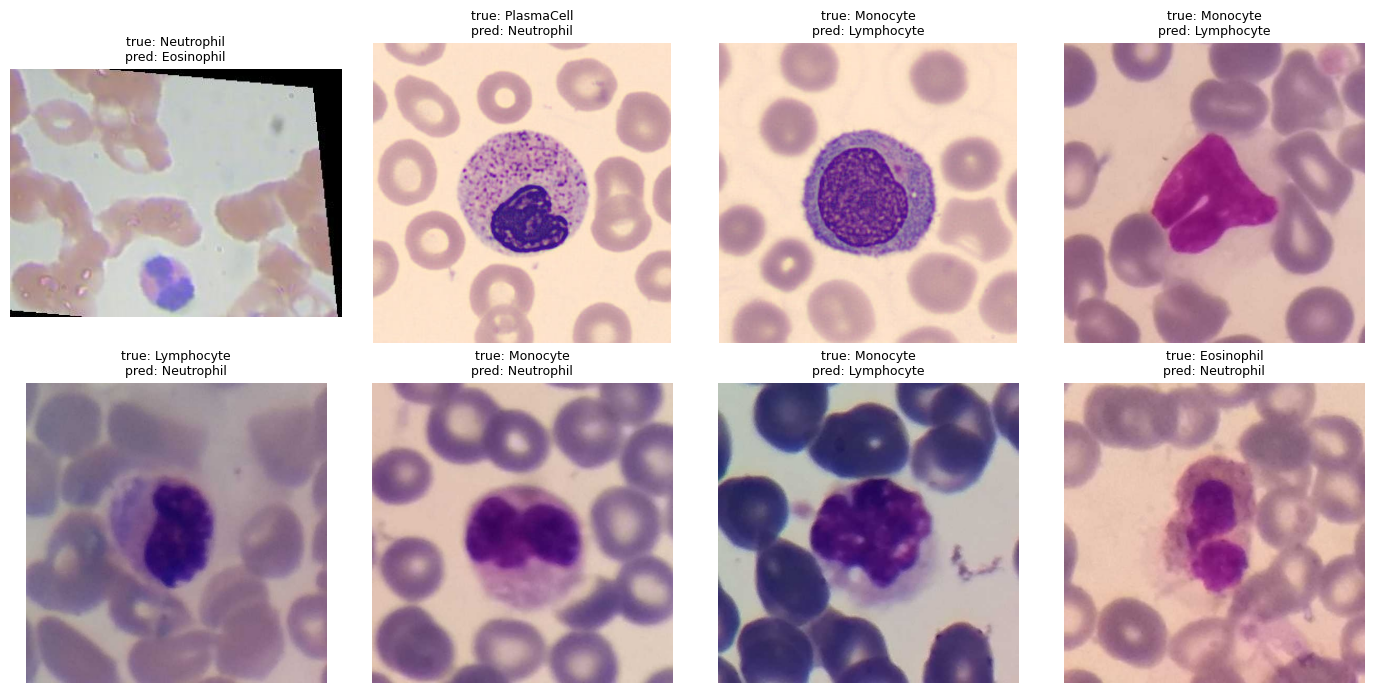

In [27]:
misclassified_idx = np.where(y_true != y_pred)[0][:8]

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, idx in zip(axes.flatten(), misclassified_idx):
    example = dataset["test"][int(idx)]
    ax.imshow(example["image"])
    ax.set_title(f"true: {id2label[y_true[idx]]}\npred: {id2label[y_pred[idx]]}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 8. Save / push the model

The model was already saved locally to `./vit-blood-cell-classifier` by `trainer.save_model()`.
Pushing to the Hub is optional and only runs if you logged in and set `PUSH_TO_HUB = True` above.

In [28]:
if PUSH_TO_HUB:
    repo_name = cfg["hub"]["repo_id"]  # set in configs/config.yaml
    trainer.push_to_hub(repo_name)
    processor.push_to_hub(repo_name)
    print(f"Model pushed to: https://huggingface.co/{repo_name}")
else:
    print("Skipping push_to_hub (PUSH_TO_HUB=False). Model is saved locally at:", output_dir)

Skipping push_to_hub (PUSH_TO_HUB=False). Model is saved locally at: /content/drive/MyDrive/vit-biomedical-finetuning/results


## 9. (Optional) Gradio demo

A minimal interactive demo: upload/drag a blood cell image, get the predicted class
and confidence scores. Great for embedding a live demo link in your portfolio
(Gradio can also be deployed for free on Hugging Face Spaces).

In [1]:
import gradio as gr
from PIL import Image
import torch.nn.functional as F

inference_model = trainer.model.eval()
device = "cuda" if torch.cuda.is_available() else "cpu"
inference_model.to(device)

def classify_blood_cell(image: Image.Image):
    image = image.convert("RGB")
    pixel_values = eval_transforms(image).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = inference_model(pixel_values=pixel_values).logits
        probs = F.softmax(logits, dim=-1)[0].cpu().numpy()
    return {id2label[i]: float(probs[i]) for i in range(num_labels)}

demo = gr.Interface(
    fn=classify_blood_cell,
    inputs=gr.Image(type="pil", label="Upload a blood cell image"),
    outputs=gr.Label(num_top_classes=8, label="Predicted class"),
    title="ViT Blood Cell Classifier",
    description=(
        "Fine-tuned google/vit-base-patch16-224 on the ehottl/blood_dataset "
        "(8 classes: basophil, eosinophil, erythroblast, lymphocyte, monocyte, "
        "neutrophil, plasma cell, platelet)."
    ),
    examples=None,
)

demo.launch(share=True, debug=False)

NameError: name 'trainer' is not defined

---
### Portfolio notes

- **Metrics to highlight:** test accuracy, macro F1 (class imbalance-aware), and the confusion
  matrix — call out which cell types are hardest to separate (e.g. visually similar WBC subtypes).
- **What to write up:** dataset composition (multi-source, 8 classes, ~46K images), why ViT
  (transfer learning from ImageNet-21k pretraining), preprocessing choices (augmentation for
  train, deterministic resize/crop for eval), and any class-imbalance handling.
- **Nice extensions:** log training curves with `report_to="tensorboard"`, add early stopping,
  try a smaller/faster backbone (e.g. `vit-tiny`/`deit`) as a speed baseline, or deploy the
  Gradio demo permanently on a free Hugging Face Space.
